# Introduction

This notebook walks throught the production of Fig. S02, which shows the frequency spectrum of the currents in the spectral analysis domain across the entire year of model output. Confidence intervals are estimated form a chi-2 distribution considering a 1-week decorrelation scale (see `../analysis/decorrelation_scale.ipynb`).

## Imports

In [28]:
import sys
sys.path.append("../src")

In [29]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from spec_plot import (
    plot_universal_spectra,
)

from spectral_analysis import (
    CI,
)

plt.rcdefaults()
plt.style.use("../src/paper.mplstyle")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data

In [3]:
INPUT_DIR = Path('../data/spectra/')

In [4]:
cur_freq_specs = xr.open_zarr(INPUT_DIR / 'freq_spec_cur.zarr', consolidated = False)

# Mean Spectra and Error Estimation

The spectra in the dataset are 1 at each lat/lon. We average all spectra cross our spectral analysis domain.

In [6]:
mean_freq_spec = cur_freq_specs.vector_variance_spectrum.mean(dim="point")

We estimate error from the chi-2 distribution. I have not estimated the spatial decorrelation scale for the surface currents in this region, yet. For now, we will take a conservative estimate of 100 km. The area of the spectral domain is approximately $A_{\text{spec}} = 6.25 \times 10^5 \text{km}^2$. The decorrelation area is $A_{\text{decor}} = 1 \times 10^4 \text{km}^2$, so $M \approx 63$.

In [10]:
M_cur_spat = 63

By default, the function computes 95% confidence intervals.

In [11]:
mean_freq_spec = CI(mean_freq_spec, M_cur_spat)

# Plotting

Some of the spectra are scaled by constants. This does not change their shape---it simply makes them appear separate on a plot.

In [18]:
figS02_styles = {
    "cur": {
        "data": mean_freq_spec,
        "color": "blue",
        "linestyle": "-",
        "label": "$\mathbf{U}_\mathrm{cur}$",
        "linewidth": 1.5,
        "plot_CI": True,
        "CI_alpha": 0.2,
    },
}

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_127537/2989936700.py:6: SyntaxWarning: invalid escape sequence '\m'
  "label": "$\mathbf{U}_\mathrm{cur}$",


In [20]:
from matplotlib.ticker import FuncFormatter

KeyError: 'Indexing with a boolean dask array is not allowed. This will result in a dask array of unknown shape. Such arrays are unsupported by Xarray.Please compute the indexer first using .compute()'

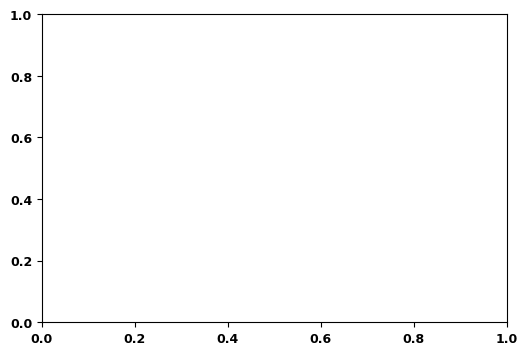

In [30]:
fig, ax = plot_universal_spectra(
    figS02_styles,
    xlim=(0.1, 10),
    ylim = (5e-5,10),
    ylab = 'Power Spectral Density [m$^2$/s$^2$/cpd]',
    xlab = 'Frequency [cpd]',
    coord='freq',
    figsize=(6,4)
)
def decimal_log_formatter(x, pos):
    return f"{x:g}"

ax.xaxis.set_major_formatter(
    FuncFormatter(decimal_log_formatter)
)

# M2 semidiurnal tide
f_M2 = 1.9323  # cycles/day

ax.axvline(
    f_M2,
    color="black",
    linestyle="--",
    linewidth=1.0,
    zorder=10
)

ax.text(
    f_M2 * 0.85,
    0.08,
    r"$M_2$",
    transform=ax.get_xaxis_transform(),
    ha="left",
    va="top",
    fontsize=10,
    rotation=90
)

Omega = 7.2921159e-5  # rad s^-1

lat_min = 32
lat_max = 39

f_min = 2 * Omega * np.sin(np.deg2rad(lat_min))
f_max = 2 * Omega * np.sin(np.deg2rad(lat_max))

# rad/s -> cycles/day
f_min_cpd = f_min / (2*np.pi) * 86400
f_max_cpd = f_max / (2*np.pi) * 86400

ax.axvspan(
    f_min_cpd,
    f_max_cpd,
    alpha=0.2,
    label=r"Local $f$ range",
)
ax.axvline(
    f_min_cpd,
    color="black",
    linestyle="--",
    linewidth=1,
)
ax.axvline(
    f_max_cpd,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.text(
    f_min_cpd * 0.85,
    0.3,
    r"Local $f$ range",
    transform=ax.get_xaxis_transform(),
    ha="left",
    va="top",
    fontsize=10,
    rotation=90
)

# Y gridlines only at major ticks
ax.grid(False, axis="y", which="minor")
ax.grid(True, axis="y", which="major")

plt.show()

In [ ]:
fig.savefig(
    '../figures/fig09.png',
    dpi=500,
    bbox_inches='tight',
    pad_inches=0.1,
)